In [1]:
import pandas as pd

from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, \
    create_error_visualization
from ml_features.features import prepare_features
from ml_features.customer_features import create_customer_features
from ml_features.sequence_features  import create_sequence_features
from ml_features.brand_features import create_brand_features
from ml_features.model_features import create_model_features
from ml_features.market_features import create_market_features
from ml_features.equipment_features import create_equipment_features
from ml_features.solution_complexity_features import create_solution_complexity_features
from ml_features.timeline_features import create_timeline_features, create_advanced_timeline_features, create_timeline_interaction_features
from ml_features.role_features import create_commercial_role_features
from ml_features.process_features import create_process_features
from ml_features.correction_features import create_correction_features
from ml_features.catboost_interaction_features import create_catboost_interaction_features
from ml_features.efficiency_interation_features import create_efficiency_interaction_features
from ml_features.engagement_interation_features import create_engagement_interaction_features
from ml_features.advanced_features import create_advanced_interaction_features, create_conversion_pattern_features, create_precision_optimization_features, create_price_dominant_features
from ml_features.price_binning_features import create_price_binning_features
from ml_features.simulation_discovery import create_simulation_discovery_features
from ml_training.train_xgb import train_xgb
from ml_evaluation.dashboard import model_evaluation_report

import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

# AC OWNERS FILTERING
print("\n🎯 FILTERING TO AC OWNERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



🎯 FILTERING TO AC OWNERS


In [2]:
# AGGREGATE CENSUS DATA BY REGION
print("\n=== AGGREGATING CENSUS DATA BY REGION ===\n")

import pandas as pd

# Load census data
census = pd.read_csv('census_commune_features.csv')
print(f"Loaded {len(census):,} communes")

# Add region mapping from department code
region_codes = {
    '11': 'Île-de-France',
    '24': 'Centre-Val de Loire',
    '27': 'Bourgogne-Franche-Comté',
    '28': 'Normandie',
    '32': 'Hauts-de-France',
    '44': 'Grand Est',
    '52': 'Pays de la Loire',
    '53': 'Bretagne',
    '75': 'Nouvelle-Aquitaine',
    '76': 'Occitanie',
    '84': 'Auvergne-Rhône-Alpes',
    '93': 'Provence-Alpes-Côte d\'Azur',
    '94': 'Corse'
}

# Extract department code (first 2 digits of INSEE)
census['dept_code'] = census['insee_code'].astype(str).str[:2]
census['region_name'] = census['dept_code'].map(region_codes).fillna('Unknown')

# Group by region
census_by_region = census.groupby('region_name').agg({
    'pct_houses': 'mean',
    'pct_pre_1970': 'mean',
    'pct_electric_heating': 'mean',
    'pct_gas_heating': 'mean',
    'pct_collective_heating': 'mean',
    'pct_other_heating': 'mean',
    'pct_ac': 'mean',
    'pct_large_home_80m2': 'mean',
    'pct_large_home_4rooms': 'mean',
    'pct_2plus_cars': 'mean',
    'pct_social_housing': 'mean',
    'housing_count': 'sum'
}).reset_index()

print("\n✅ Census data aggregated by region:")
print(census_by_region.to_string())

df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])
print(f"\n📊 Original quote data: {len(df_quotes):,} quotes from {df_quotes['numero_compte'].nunique():,} customers")

print("\n" + "=" * 80)
print("🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS")
print("=" * 80)

feature_funcs = [create_customer_features, create_sequence_features, create_brand_features,
                 create_model_features, create_market_features,
                 create_equipment_features, create_solution_complexity_features,
                 create_timeline_features, create_advanced_timeline_features,
                 create_commercial_role_features, create_process_features,
                 create_correction_features
                 ]

new_df = feature_funcs[0](df_quotes)
for func in feature_funcs[1:]:
    new_df_ = func(df_quotes)
    new_df = pd.merge(new_df, new_df_, on='numero_compte', how='left', suffixes=('_dup', ''))
    new_df = new_df.drop(columns=[x for x in new_df.columns if '_dup' in x], errors='ignore')

print(f"\n✅ Customer-level features created: {len(new_df):,} customers")

print("\n" + "=" * 80)
print("🔧 ADDING INTERACTION FEATURES")
print("=" * 80)

new_df = create_timeline_interaction_features(new_df)
new_df, _ = create_catboost_interaction_features(new_df)
new_df, _ = create_efficiency_interaction_features(new_df)
new_df, _ = create_engagement_interaction_features(new_df)
new_df = create_advanced_interaction_features(new_df)
new_df = create_conversion_pattern_features(new_df)
new_df = create_precision_optimization_features(new_df)
new_df = create_price_dominant_features(new_df)
new_df = create_price_binning_features(new_df)
new_df = create_simulation_discovery_features(new_df)

df_enriched = new_df.merge(
    census_by_region,
    left_on='main_region',
    right_on='region_name',
    how='left'
)

print(f"\n✅ Enriched {len(df_enriched):,} customers")
print(f"Missing regions: {df_enriched['pct_houses'].isna().sum():,}")

# Show sample
print("\nSample of enriched customer data:")
print(df_enriched.head(10))


new_df = df_enriched

print("\n" + "=" * 80)
print("🔧 ENCODING & PREPARING FOR MODELING")
print("=" * 80)

X = new_df.drop(columns=['numero_compte', 'converted'], errors='ignore')
y = new_df['converted']
X_clean, y_clean = prepare_features(X, y, "Cold Region Features")

print(f"   Features: {X_clean.shape[1]}, Samples: {X_clean.shape[0]}")


=== AGGREGATING CENSUS DATA BY REGION ===

Loaded 34,914 communes

✅ Census data aggregated by region:
                   region_name  pct_houses  pct_pre_1970  pct_electric_heating  pct_gas_heating  pct_collective_heating  pct_other_heating  pct_ac  pct_large_home_80m2  pct_large_home_4rooms  pct_2plus_cars  pct_social_housing  housing_count
0         Auvergne-Rhône-Alpes    0.837924      0.366486                   0.0              0.0                     0.0                0.0     0.0             0.862476               0.735893        0.487691                 0.0   2.595838e+05
1      Bourgogne-Franche-Comté    0.956845      0.403678                   0.0              0.0                     0.0                0.0     0.0             0.924609               0.833716        0.562710                 0.0   2.611931e+05
2                     Bretagne    0.963575      0.485918                   0.0              0.0                     0.0                0.0     0.0             0.918871   

In [5]:
print(list(X_clean.columns))

['std_days_between_quotes', 'price_trajectory', 'unique_product_families', 'avg_discount_pct', 'main_agency', 'main_region', 'total_historical_quotes', 'had_historical_quotes', 'avg_days_since_first_quote', 'std_days_since_first_quote', 'avg_recent_quote_count', 'std_recent_quote_count', 'avg_recent_avg_price', 'std_recent_avg_price', 'avg_recent_price_std', 'std_recent_price_std', 'avg_recent_product_variety', 'std_recent_product_variety', 'avg_current_price', 'std_current_price', 'price_trend', 'product_consistency', 'nom_agence', 'nom_region', 'brand_data_available', 'brand_loyalty_index', 'brand_switches', 'prefers_premium_brand', 'prefers_budget_brand', 'brand_persistence_ratio', 'brand_convergence', 'model_data_available', 'avg_model_name_length', 'model_name_complexity', 'technical_model_ratio', 'standard_model_ratio', 'has_efficiency_class', 'efficiency_class_score', 'model_variety_score', 'series_consistency', 'unique_series_count', 'avg_kw_rating', 'kw_range', 'dominant_model


🚀 TRAINING MODEL ON SUBPOPULATION CUSTOMERS
✓ Model saved: region_census_model.pkl
✓ AUC: 0.767
✓ F1 Score: 0.623
✓ Training samples: 20572
✓ Test samples: 5144

📊 MODEL EVALUATION - REGION CENSUS CUSTOMERS
COMPLETE MODEL VALIDATION PACKAGE

📊 STEP 1: DISCRIMINATION POWER
----------------------------------------


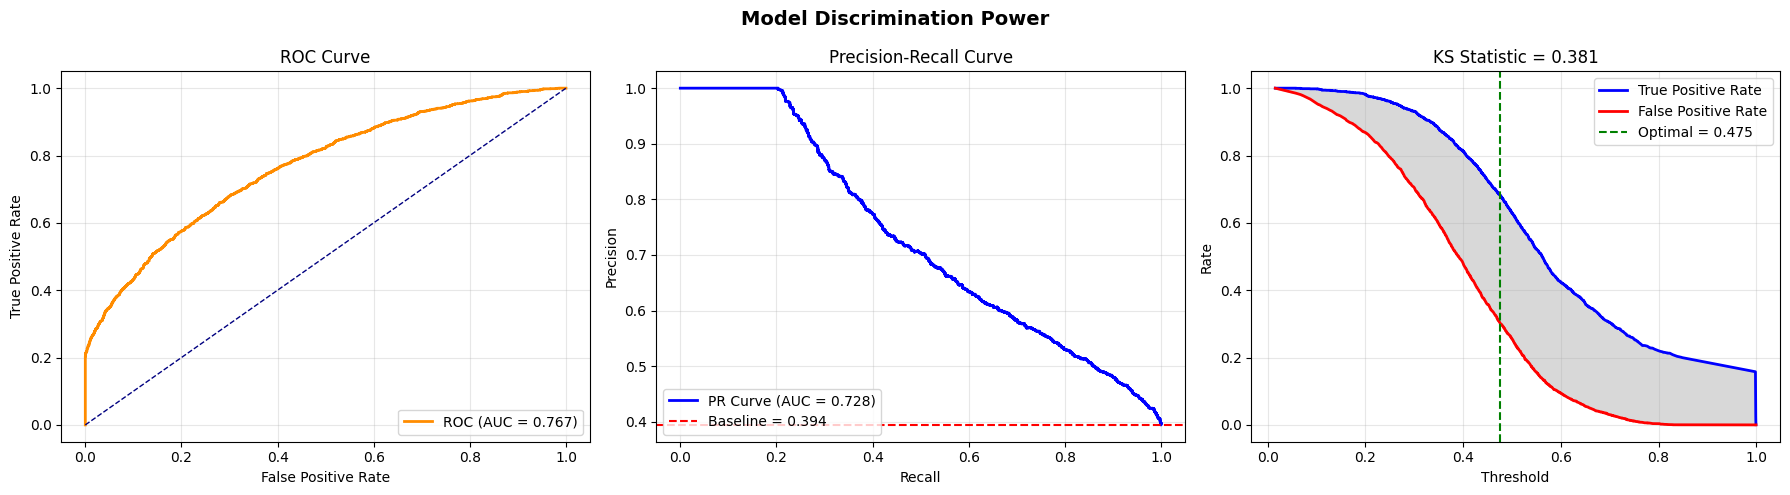

• ROC-AUC: 0.7669
• PR-AUC: 0.7276
• KS Statistic: 0.381 (MODERATE discrimination)
• Optimal Threshold: 0.475

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.953
Decile 10 mean prob: 0.136


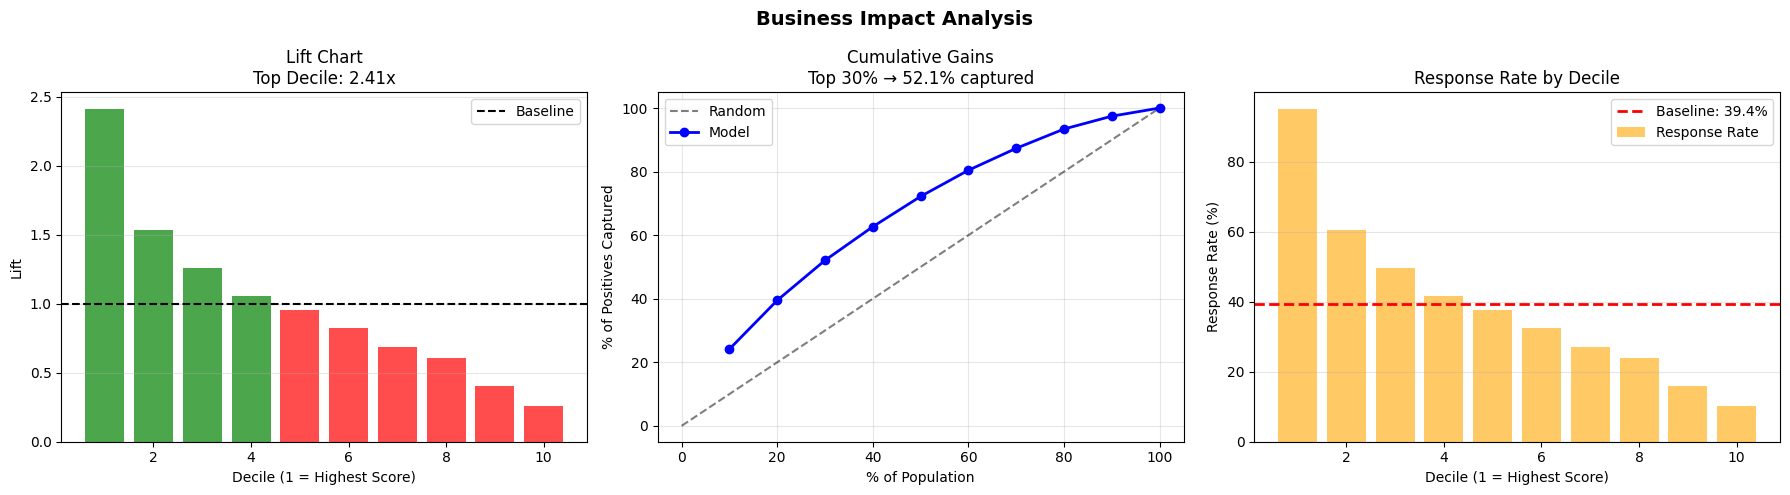

• Top Decile Lift: 0.26x
• Top 30% captures: 52.1% of positives
• Baseline response rate: 39.4%
• Top decile response: 95.1%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


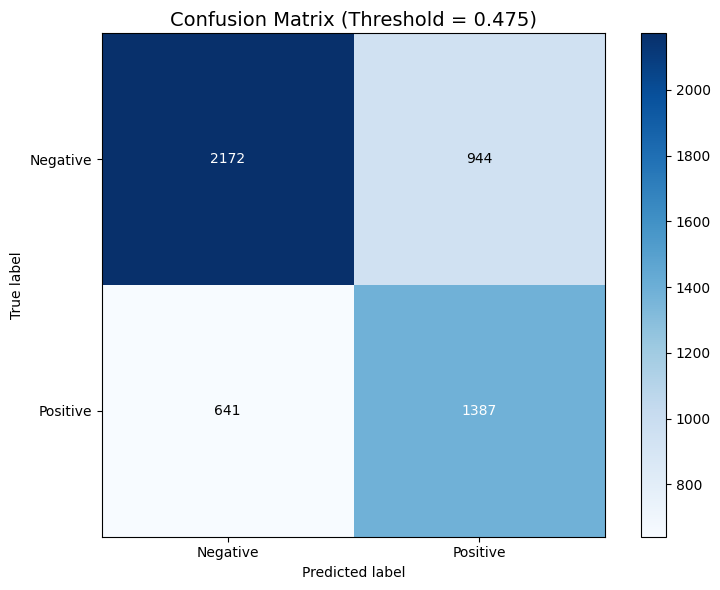

At threshold 0.475:
• Accuracy: 0.692
• Precision: 0.595
• Recall: 0.684
• F1-Score: 0.636
• True Positives: 1387
• False Positives: 944
• True Negatives: 2172
• False Negatives: 641

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.381 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.26x better than random
   Coverage: Top 30% → 52.1% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7669 (Excellent if >0.8)
   PR-AUC: 0.7276 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.475
   Precision at threshold: 0.595
   Recall at threshold: 0.684

🔍 FEATURE IMPORTANCE - REGION CENSUS MODEL

Top 20 Features:
                                     feature  importance
178                  quote_consistency_score    0.122295
167                         is_quick_decider    0.046616
180                decision_efficiency_score    0.030873
250                              value_score    0.030241
214                   speed_complexity_ratio    0.019268
205   

In [11]:
print("\n" + "=" * 80)
print("🚀 TRAINING MODEL ON SUBPOPULATION CUSTOMERS")
print("=" * 80)

result = train_xgb(X_clean, y_clean, 'region_census_model')

print("\n" + "=" * 80)
print("📊 MODEL EVALUATION - REGION CENSUS CUSTOMERS")
print("=" * 80)

df_eval = result['X_test'].copy()
df_eval['converted'] = result['y_test']

model_evaluation_report(df_eval, result['model'], result['features'], 'converted')

print("\n" + "=" * 80)
print("🔍 FEATURE IMPORTANCE - REGION CENSUS MODEL")
print("=" * 80)

feature_importance = pd.DataFrame({
    'feature': result['features'],
    'importance': result['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(feature_importance.head(50))

print("\n" + "=" * 80)
print("🧪 SIMULATION-DISCOVERY FEATURES IN SUBPOPULATION MODEL")
print("=" * 80)

simulation_features = [
    'heat_pump_to_stove_opportunity',
    'boiler_to_ac_opportunity',
    'cold_region_heat_pump',
    'cold_heat_pump_to_stove',
    'follow_up_opportunity'
]

print("\nFeature Importances for Simulation-Discovery Features:")
for feat in simulation_features:
    if feat in feature_importance['feature'].values:
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
        print(f"  #{rank}: {feat}: {imp:.4f}")
    else:
        print(f"  ❌ {feat}: NOT FOUND")

print("\n" + "=" * 80)
print("✅ MODEL TRAINING COMPLETE")
print("=" * 80)

if feat in feature_importance['feature'].values:
    imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
    print(f"  #{rank}: {feat}: {imp:.4f}")
else:
    print(f"  ❌ {feat}: NOT FOUND")